In [176]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Evaluate across seeds

## Rolling window = 5

In [287]:
rolling_window = 5

In [288]:
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [188]:
variables_toplot = [
'diagprog_prop', 'comm_prop', 
'disgust_prob', 'neutral_prob',
 '1|election_state[CO]', '1|election_state[NV]', '1|election_state[RI]', '1|election_state[WA]', 
 '1|election_state[ID]', '1|election_state[OH]', '1|election_state_sigma']

In [289]:
variables_toplot = ['Intercept', 'diagprog_prop', 'mot_prop', 'comm_prop', 'eng_prop',
 'anger_prob', 'disgust_prob', 'fear_prob', 'joy_prob','neutral_prob',
 'sadness_prob', 'surprise_prob', 'standardize(size)', 'standardize(assets)',
 'standardize(Disbursement)', 'standardize(Liabilities)',
 'standardize(weekly_posts_mean)', 'primary_industry[Construction]',
 'primary_industry[Educational Services]',
 'primary_industry[Federal Government]',
 'primary_industry[Health Care and Social Assistance]',
 'primary_industry[Manufacturing]', 'primary_industry[Maritime]',
 'primary_industry[Personal Serv & Private Organizations]',
 'primary_industry[Retail Trade]', 'primary_industry[Transportation]',
 'primary_industry[Transportation and Warehousing]',
 'primary_industry[Utilities]', 'type[Industrial]', 'rightwork',
 '1|union_sigma', '1|election_state_sigma', '1|union[afm]', '1|union[afscme]',
 '1|union[aft]', '1|union[atu]', '1|union[bac]', '1|union[bctgm]',
 '1|union[cwa]', '1|union[iaff]', '1|union[iam]', '1|union[iatse]',
 '1|union[ibb]', '1|union[ibew]', '1|union[ibt]', '1|union[ifpte]',
 '1|union[ironworkers]', '1|union[iupat]', '1|union[liuna]', '1|union[natca]',
 '1|union[nea]', '1|union[nnu]', '1|union[opeiu]', '1|union[seiu]',
 '1|union[siu]', '1|union[smart]', '1|union[twu]', '1|union[ua]',
 '1|union[uaw]', '1|union[ufcw]', '1|union[unite here]', '1|union[usw]',
 '1|union[uwua]', '1|election_state[AK]', '1|election_state[AL]',
 '1|election_state[AR]', '1|election_state[AZ]', '1|election_state[CA]',
 '1|election_state[CO]', '1|election_state[CT]', '1|election_state[DC]',
 '1|election_state[DE]', '1|election_state[FL]', '1|election_state[GA]',
 '1|election_state[GU]', '1|election_state[HI]', '1|election_state[IA]',
 '1|election_state[ID]', '1|election_state[IL]', '1|election_state[IN]',
 '1|election_state[KS]', '1|election_state[KY]', '1|election_state[LA]',
 '1|election_state[MA]', '1|election_state[MD]', '1|election_state[ME]',
 '1|election_state[MI]', '1|election_state[MN]', '1|election_state[MO]',
 '1|election_state[MS]', '1|election_state[MT]', '1|election_state[NC]',
 '1|election_state[ND]', '1|election_state[NE]', '1|election_state[NH]',
 '1|election_state[NJ]', '1|election_state[NM]', '1|election_state[NV]',
 '1|election_state[NY]', '1|election_state[OH]', '1|election_state[OK]',
 '1|election_state[OR]', '1|election_state[PA]', '1|election_state[PR]',
 '1|election_state[RI]', '1|election_state[SC]', '1|election_state[SD]',
 '1|election_state[TN]', '1|election_state[TX]', '1|election_state[UT]',
 '1|election_state[VA]', '1|election_state[VI]', '1|election_state[VT]',
 '1|election_state[WA]', '1|election_state[WI]', '1|election_state[WV]',
 '1|election_state[WY]']

In [ ]:
first = True
for seed in seed_list:
    df = pd.read_csv(f"../data/bayesian_model_summary-rolling_diag+prog_window_{rolling_window}_seed{seed}-moredata_staterandom.csv")

    if df.columns[0] != "variable":
        df = df.rename(columns={df.columns[0]: "variable"})

    if first:
        df_allseeds = df[df["variable"].isin(variables_toplot)]
        first = False
        # rename all columns except "variable" to have suffix _seed{seed}
    else:
        df_allseeds = df_allseeds.merge(df[df["variable"].isin(variables_toplot)], on="variable", suffixes=('', f'_seed{seed}'), how='outer')

    df_allseeds = df_allseeds.rename(columns={col: f"{col}_seed{seed}" for col in df_allseeds.columns if (col != "variable" and "seed" not in col)})

In [291]:
# for all variables, compute the mean across seeds 
list_means = []
for var in df_allseeds["variable"]:
    means = []
    for seed in seed_list:
        means.append(df_allseeds.loc[df_allseeds["variable"] == var, f"mean_seed{seed}"].values[0])
    mean_across_seeds = np.mean(means)
    list_means.append({"variable": var, "mean_across_seeds": mean_across_seeds})

In [292]:
df_allseeds["mean_across_seeds"] = [item["mean_across_seeds"] for item in list_means]

In [192]:
# rename variables for plotting
df_allseeds["variable"] = df_allseeds["variable"].replace({
    "diagprog_prop": "Diagnostic\nor Prognostic",
    "mot_prop": "Motivational",
    "comm_prop": "Community",
    "eng_prop": "Engagement",
    "disgust_prob": "Disgust",
    "neutral_prob": "Neutral",
    "anger_prob": "Anger",
    "1|election_state[CO]": "Random Effect:\nState CO", 
    "1|election_state[ID]": "Random Effect:\nState ID",
    "1|election_state[OH]": "Random Effect:\nState OH",
    "1|election_state[NV]": "Random Effect:\nState NV",
    "1|election_state[RI]": "Random Effect:\nState RI",
    "1|election_state[WA]": "Random Effect:\nState WA",
    "1|election_state_sigma": "Random Effect:\nState Sigma"})

In [293]:
df_allseeds[["variable", "mean_across_seeds"]]

,variable,mean_across_seeds
0,Intercept,-0.2547
1,diagprog_prop,0.3384
2,mot_prop,-0.1632
3,comm_prop,0.2504
4,eng_prop,-0.0227
...,...,...
112,1|election_state[VT],0.1253
113,1|election_state[WA],0.4346
114,1|election_state[WI],0.1357
115,1|election_state[WV],-0.1318


In [194]:
# ---- count significant seeds per variable ----
sig_counts = []

for idx in range(len(df_allseeds)):
    count = 0
    for i in seed_list:
        low = df_allseeds.loc[idx, f"hdi_5%_seed{i}"]
        high = df_allseeds.loc[idx, f"hdi_95%_seed{i}"]

        # significant if interval excludes 0
        if (low > 0) or (high < 0):
            count += 1

    sig_counts.append(count)

df_allseeds["sig_seed_count"] = sig_counts

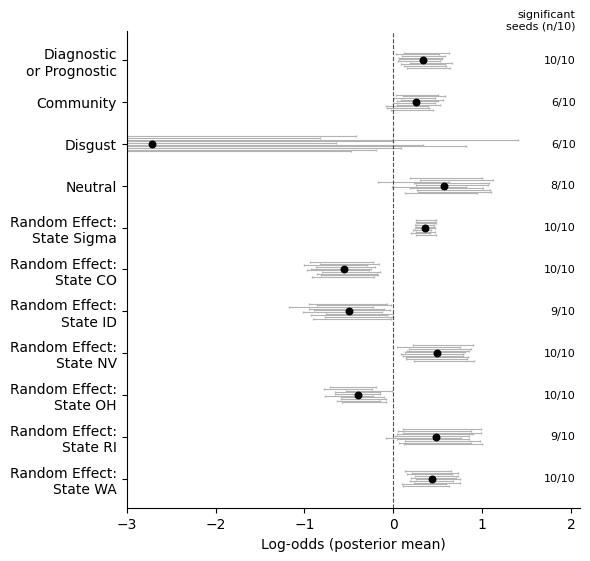

In [ ]:
df_allseeds = df_allseeds.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6, 0.5 * len(df_allseeds)))

y = np.arange(len(df_allseeds))

# ---- Seed-level HDIs (thin, light grey) ----
seed_cols = [(f"mean_seed{i}", f"hdi_5%_seed{i}", f"hdi_95%_seed{i}") for i in seed_list]

offsets = np.linspace(-0.18, 0.18, len(seed_cols))

for (mean_col, low_col, high_col), off in zip(seed_cols, offsets):
    seed_means = df_allseeds[mean_col]
    seed_low = df_allseeds[low_col]
    seed_high = df_allseeds[high_col]

    lower = seed_means - seed_low
    upper = seed_high - seed_means

    ax.errorbar(
        seed_means,
        y + off,
        xerr=[lower, upper],
        fmt='none',
        ecolor='0.7',       # grayscale-safe
        elinewidth=0.8,
        capsize=1,
        zorder=1
    )

# ---- Across-seed posterior mean (dominant) ----
mean_across = df_allseeds["mean_across_seeds"]

ax.scatter(
    mean_across,
    y,
    c='black',
    s=22,
    zorder=3
)

# ---- Zero reference line ----
ax.axvline(0, color='0.3', linestyle='--', linewidth=0.8)

# ---- Axis formatting ----
ax.set_yticks(y)
ax.set_yticklabels(df_allseeds["variable"])
ax.set_xlabel("Log-odds (posterior mean)")

ax.set_xlim(-3, 2.1)

sns.despine()

plt.tight_layout()

# ---- annotate: significant seeds ----
x_text = ax.get_xlim()[1] - 0.05  # right margin

for i, count in enumerate(df_allseeds["sig_seed_count"]):
    ax.text(
        x_text,
        i,
        f"{count}/{len(seed_list)}",
        va='center',
        ha='right',
        fontsize=8,
        color='black'
    )

# optional column label at top
ax.text(
    x_text,
    len(y) - 0.3,
    f"significant\nseeds (n/{len(seed_list)})",
    ha='right',
    va='bottom',
    fontsize=8
)

#plt.show()
plt.savefig("../data/plots/bayesian_model_coefficients_rolling5_diagprog-moredata.svg")


## Rolling window = 3

In [207]:
rolling_window = 3

In [208]:
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
# variables_toplot = ['Intercept', 'diagprog_prop', 'mot_prop', 'comm_prop', 'eng_prop',
#  'anger_prob', 'disgust_prob', 'fear_prob', 'joy_prob','neutral_prob',
#  'sadness_prob', 'surprise_prob', 'standardize(size)', 'standardize(assets)',
#  'standardize(Disbursement)', 'standardize(Liabilities)',
#  'standardize(weekly_posts_mean)', 'primary_industry[Construction]',
#  'primary_industry[Educational Services]',
#  'primary_industry[Federal Government]',
#  'primary_industry[Health Care and Social Assistance]',
#  'primary_industry[Manufacturing]', 'primary_industry[Maritime]',
#  'primary_industry[Personal Serv & Private Organizations]',
#  'primary_industry[Retail Trade]', 'primary_industry[Transportation]',
#  'primary_industry[Transportation and Warehousing]',
#  'primary_industry[Utilities]', 'type[Industrial]', 'rightwork',
#  '1|union_sigma', '1|election_state_sigma', '1|union[afm]', '1|union[afscme]',
#  '1|union[aft]', '1|union[atu]', '1|union[bac]', '1|union[bctgm]',
#  '1|union[cwa]', '1|union[iaff]', '1|union[iam]', '1|union[iatse]',
#  '1|union[ibb]', '1|union[ibew]', '1|union[ibt]', '1|union[ifpte]',
#  '1|union[ironworkers]', '1|union[iupat]', '1|union[liuna]', '1|union[natca]',
#  '1|union[nea]', '1|union[nnu]', '1|union[opeiu]', '1|union[seiu]',
#  '1|union[siu]', '1|union[smart]', '1|union[twu]', '1|union[ua]',
#  '1|union[uaw]', '1|union[ufcw]', '1|union[unite here]', '1|union[usw]',
#  '1|union[uwua]', '1|election_state[AK]', '1|election_state[AL]',
#  '1|election_state[AR]', '1|election_state[AZ]', '1|election_state[CA]',
#  '1|election_state[CO]', '1|election_state[CT]', '1|election_state[DC]',
#  '1|election_state[DE]', '1|election_state[FL]', '1|election_state[GA]',
#  '1|election_state[GU]', '1|election_state[HI]', '1|election_state[IA]',
#  '1|election_state[ID]', '1|election_state[IL]', '1|election_state[IN]',
#  '1|election_state[KS]', '1|election_state[KY]', '1|election_state[LA]',
#  '1|election_state[MA]', '1|election_state[MD]', '1|election_state[ME]',
#  '1|election_state[MI]', '1|election_state[MN]', '1|election_state[MO]',
#  '1|election_state[MS]', '1|election_state[MT]', '1|election_state[NC]',
#  '1|election_state[ND]', '1|election_state[NE]', '1|election_state[NH]',
#  '1|election_state[NJ]', '1|election_state[NM]', '1|election_state[NV]',
#  '1|election_state[NY]', '1|election_state[OH]', '1|election_state[OK]',
#  '1|election_state[OR]', '1|election_state[PA]', '1|election_state[PR]',
#  '1|election_state[RI]', '1|election_state[SC]', '1|election_state[SD]',
#  '1|election_state[TN]', '1|election_state[TX]', '1|election_state[UT]',
#  '1|election_state[VA]', '1|election_state[VI]', '1|election_state[VT]',
#  '1|election_state[WA]', '1|election_state[WI]', '1|election_state[WV]',
#  '1|election_state[WY]']

In [209]:
# variables_toplot = [
# 'diagprog_prop', 'comm_prop', 
# 'disgust_prob', 'neutral_prob',
#  '1|election_state[CO]', 
#  '1|election_state[ID]', '1|election_state[OH]', '1|election_state_sigma']
variables_toplot = ['diagprog_prop', 'neutral_prob', '1|election_state_sigma', 
                    '1|election_state[AZ]',
 '1|election_state[CO]', '1|election_state[ID]', '1|election_state[NV]',
 '1|election_state[OH]', 
 '1|election_state[RI]', 
 '1|election_state[WA]']

In [ ]:
first = True
for seed in seed_list:
    df = pd.read_csv(f"../data/bayesian_model_summary-rolling_diag+prog_window_{rolling_window}_seed{seed}-moredata_staterandom.csv")

    if df.columns[0] != "variable":
        df = df.rename(columns={df.columns[0]: "variable"})

    # print(df["variable"].unique())
    # break

    if first:
        df_allseeds = df[df["variable"].isin(variables_toplot)]
        first = False
        # rename all columns except "variable" to have suffix _seed{seed}
    else:
        df_allseeds = df_allseeds.merge(df[df["variable"].isin(variables_toplot)], on="variable", suffixes=('', f'_seed{seed}'), how='outer')

    df_allseeds = df_allseeds.rename(columns={col: f"{col}_seed{seed}" for col in df_allseeds.columns if (col != "variable" and "seed" not in col)})

In [211]:
df_allseeds.columns

Index(['variable', 'mean_seed0', 'sd_seed0', 'hdi_5%_seed0', 'hdi_95%_seed0',
       'mcse_mean_seed0', 'mcse_sd_seed0', 'ess_bulk_seed0', 'ess_tail_seed0',
       'r_hat_seed0', 'mean_seed1', 'sd_seed1', 'hdi_5%_seed1',
       'hdi_95%_seed1', 'mcse_mean_seed1', 'mcse_sd_seed1', 'ess_bulk_seed1',
       'ess_tail_seed1', 'r_hat_seed1', 'mean_seed2', 'sd_seed2',
       'hdi_5%_seed2', 'hdi_95%_seed2', 'mcse_mean_seed2', 'mcse_sd_seed2',
       'ess_bulk_seed2', 'ess_tail_seed2', 'r_hat_seed2', 'mean_seed3',
       'sd_seed3', 'hdi_5%_seed3', 'hdi_95%_seed3', 'mcse_mean_seed3',
       'mcse_sd_seed3', 'ess_bulk_seed3', 'ess_tail_seed3', 'r_hat_seed3',
       'mean_seed4', 'sd_seed4', 'hdi_5%_seed4', 'hdi_95%_seed4',
       'mcse_mean_seed4', 'mcse_sd_seed4', 'ess_bulk_seed4', 'ess_tail_seed4',
       'r_hat_seed4', 'mean_seed5', 'sd_seed5', 'hdi_5%_seed5',
       'hdi_95%_seed5', 'mcse_mean_seed5', 'mcse_sd_seed5', 'ess_bulk_seed5',
       'ess_tail_seed5', 'r_hat_seed5', 'mean_seed6', 

In [212]:
# for all variables, compute the mean across seeds 
list_means = []
for var in df_allseeds["variable"]:
    means = []
    for seed in seed_list:
        means.append(df_allseeds.loc[df_allseeds["variable"] == var, f"mean_seed{seed}"].values[0])
    mean_across_seeds = np.mean(means)
    list_means.append({"variable": var, "mean_across_seeds": mean_across_seeds})

In [213]:
df_allseeds["mean_across_seeds"] = [item["mean_across_seeds"] for item in list_means]

In [214]:
# rename variables for plotting
df_allseeds["variable"] = df_allseeds["variable"].replace({
    "diagprog_prop": "Diagnostic\nor Prognostic",
    "mot_prop": "Motivational",
    "comm_prop": "Community",
    "eng_prop": "Engagement",
    "disgust_prob": "Disgust",
    "neutral_prob": "Neutral",
    "anger_prob": "Anger",
    "1|election_state[AZ]": "Random Effect:\nState AZ", 
    "1|election_state[CO]": "Random Effect:\nState CO", 
    "1|election_state[ID]": "Random Effect:\nState ID",
    "1|election_state[OH]": "Random Effect:\nState OH",
    "1|election_state[RI]": "Random Effect:\nState RI",
    "1|election_state[NV]": "Random Effect:\nState NV",
    "1|election_state[WA]": "Random Effect:\nState WA",
    "1|election_state_sigma": "Random Effect:\nState Sigma"})

In [215]:
# ---- count significant seeds per variable ----
sig_counts = []

for idx in range(len(df_allseeds)):
    count = 0
    for i in seed_list:
        low = df_allseeds.loc[idx, f"hdi_5%_seed{i}"]
        high = df_allseeds.loc[idx, f"hdi_95%_seed{i}"]

        # significant if interval excludes 0
        if (low > 0) or (high < 0):
            count += 1

    sig_counts.append(count)

df_allseeds["sig_seed_count"] = sig_counts

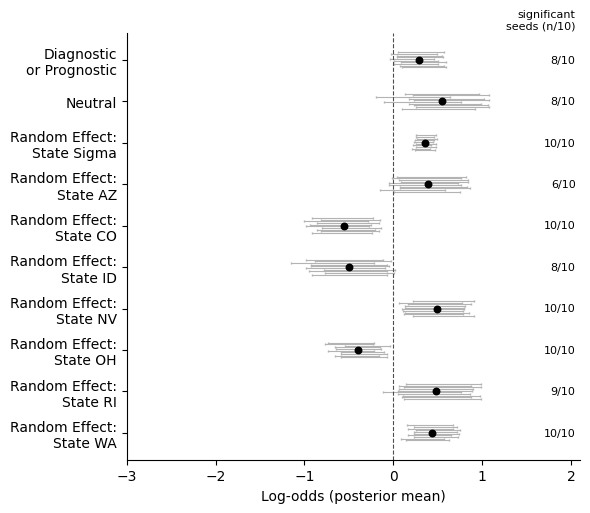

In [ ]:
df_allseeds = df_allseeds.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6, 0.5 * len(df_allseeds)))

y = np.arange(len(df_allseeds))

# ---- Seed-level HDIs (thin, light grey) ----
seed_cols = [(f"mean_seed{i}", f"hdi_5%_seed{i}", f"hdi_95%_seed{i}") for i in seed_list]

offsets = np.linspace(-0.18, 0.18, len(seed_cols))

for (mean_col, low_col, high_col), off in zip(seed_cols, offsets):
    seed_means = df_allseeds[mean_col]
    seed_low = df_allseeds[low_col]
    seed_high = df_allseeds[high_col]

    lower = seed_means - seed_low
    upper = seed_high - seed_means

    ax.errorbar(
        seed_means,
        y + off,
        xerr=[lower, upper],
        fmt='none',
        ecolor='0.7',       # grayscale-safe
        elinewidth=0.8,
        capsize=1,
        zorder=1
    )

# ---- Across-seed posterior mean (dominant) ----
mean_across = df_allseeds["mean_across_seeds"]

ax.scatter(
    mean_across,
    y,
    c='black',
    s=22,
    zorder=3
)

# ---- Zero reference line ----
ax.axvline(0, color='0.3', linestyle='--', linewidth=0.8)

# ---- Axis formatting ----
ax.set_yticks(y)
ax.set_yticklabels(df_allseeds["variable"])
ax.set_xlabel("Log-odds (posterior mean)")

ax.set_xlim(-3, 2.1)

sns.despine()

plt.tight_layout()

# ---- annotate: significant seeds ----
x_text = ax.get_xlim()[1] - 0.05  # right margin

for i, count in enumerate(df_allseeds["sig_seed_count"]):
    ax.text(
        x_text,
        i,
        f"{count}/{len(seed_list)}",
        va='center',
        ha='right',
        fontsize=8,
        color='black'
    )

# optional column label at top
ax.text(
    x_text,
    len(y) - 0.3,
    f"significant\nseeds (n/{len(seed_list)})",
    ha='right',
    va='bottom',
    fontsize=8
)

plt.savefig("../data/plots/bayesian_model_coefficients_rolling3_diagprog.svg")


## Rolling window = 5, only diag

In [221]:
rolling_window = 5

In [222]:
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [230]:
variables_toplot = [
    #'Intercept',
'diag_prop',
 'comm_prop',
 # 'fear_prob',
 #'joy_prob',
 'neutral_prob',
 '1|election_state[CO]', '1|election_state[NV]', '1|election_state[RI]', '1|election_state[WA]', 
 '1|election_state[ID]', '1|election_state[OH]', '1|election_state_sigma'
 ]

In [ ]:
# variables_toplot = ['diag_prop', 'mot_prop', 'comm_prop', 'eng_prop',
#  'anger_prob', 'disgust_prob', 'fear_prob', 'joy_prob','neutral_prob',
#  'sadness_prob', 'surprise_prob', 'standardize(size)', 'standardize(assets)',
#  'standardize(Disbursement)', 'standardize(Liabilities)',
#  'standardize(weekly_posts_mean)', 'primary_industry[Construction]',
#  'primary_industry[Educational Services]',
#  'primary_industry[Federal Government]',
#  'primary_industry[Health Care and Social Assistance]',
#  'primary_industry[Manufacturing]', 'primary_industry[Maritime]',
#  'primary_industry[Personal Serv & Private Organizations]',
#  'primary_industry[Retail Trade]', 'primary_industry[Transportation]',
#  'primary_industry[Transportation and Warehousing]',
#  'primary_industry[Utilities]', 'type[Industrial]', 'rightwork',
#  '1|union_sigma', '1|election_state_sigma', '1|union[afm]', '1|union[afscme]',
#  '1|union[aft]', '1|union[atu]', '1|union[bac]', '1|union[bctgm]',
#  '1|union[cwa]', '1|union[iaff]', '1|union[iam]', '1|union[iatse]',
#  '1|union[ibb]', '1|union[ibew]', '1|union[ibt]', '1|union[ifpte]',
#  '1|union[ironworkers]', '1|union[iupat]', '1|union[liuna]', '1|union[natca]',
#  '1|union[nea]', '1|union[nnu]', '1|union[opeiu]', '1|union[seiu]',
#  '1|union[siu]', '1|union[smart]', '1|union[twu]', '1|union[ua]',
#  '1|union[uaw]', '1|union[ufcw]', '1|union[unite here]', '1|union[usw]',
#  '1|union[uwua]', '1|election_state[AK]', '1|election_state[AL]',
#  '1|election_state[AR]', '1|election_state[AZ]', '1|election_state[CA]',
#  '1|election_state[CO]', '1|election_state[CT]', '1|election_state[DC]',
#  '1|election_state[DE]', '1|election_state[FL]', '1|election_state[GA]',
#  '1|election_state[GU]', '1|election_state[HI]', '1|election_state[IA]',
#  '1|election_state[ID]', '1|election_state[IL]', '1|election_state[IN]',
#  '1|election_state[KS]', '1|election_state[KY]', '1|election_state[LA]',
#  '1|election_state[MA]', '1|election_state[MD]', '1|election_state[ME]',
#  '1|election_state[MI]', '1|election_state[MN]', '1|election_state[MO]',
#  '1|election_state[MS]', '1|election_state[MT]', '1|election_state[NC]',
#  '1|election_state[ND]', '1|election_state[NE]', '1|election_state[NH]',
#  '1|election_state[NJ]', '1|election_state[NM]', '1|election_state[NV]',
#  '1|election_state[NY]', '1|election_state[OH]', '1|election_state[OK]',
#  '1|election_state[OR]', '1|election_state[PA]', '1|election_state[PR]',
#  '1|election_state[RI]', '1|election_state[SC]', '1|election_state[SD]',
#  '1|election_state[TN]', '1|election_state[TX]', '1|election_state[UT]',
#  '1|election_state[VA]', '1|election_state[VI]', '1|election_state[VT]',
#  '1|election_state[WA]', '1|election_state[WI]', '1|election_state[WV]',
#  '1|election_state[WY]']

In [ ]:
first = True
for seed in seed_list:
    df = pd.read_csv(f"../data/bayesian_model_summary-rolling_diag_window_{rolling_window}_seed{seed}-moredata_staterandom.csv")

    if df.columns[0] != "variable":
        df = df.rename(columns={df.columns[0]: "variable"})

    if first:
        df_allseeds = df[df["variable"].isin(variables_toplot)]
        first = False
        # rename all columns except "variable" to have suffix _seed{seed}
    else:
        df_allseeds = df_allseeds.merge(df[df["variable"].isin(variables_toplot)], on="variable", suffixes=('', f'_seed{seed}'), how='outer')

    df_allseeds = df_allseeds.rename(columns={col: f"{col}_seed{seed}" for col in df_allseeds.columns if (col != "variable" and "seed" not in col)})

In [232]:
df_allseeds.columns

Index(['variable', 'mean_seed0', 'sd_seed0', 'hdi_5%_seed0', 'hdi_95%_seed0',
       'mcse_mean_seed0', 'mcse_sd_seed0', 'ess_bulk_seed0', 'ess_tail_seed0',
       'r_hat_seed0', 'mean_seed1', 'sd_seed1', 'hdi_5%_seed1',
       'hdi_95%_seed1', 'mcse_mean_seed1', 'mcse_sd_seed1', 'ess_bulk_seed1',
       'ess_tail_seed1', 'r_hat_seed1', 'mean_seed2', 'sd_seed2',
       'hdi_5%_seed2', 'hdi_95%_seed2', 'mcse_mean_seed2', 'mcse_sd_seed2',
       'ess_bulk_seed2', 'ess_tail_seed2', 'r_hat_seed2', 'mean_seed3',
       'sd_seed3', 'hdi_5%_seed3', 'hdi_95%_seed3', 'mcse_mean_seed3',
       'mcse_sd_seed3', 'ess_bulk_seed3', 'ess_tail_seed3', 'r_hat_seed3',
       'mean_seed4', 'sd_seed4', 'hdi_5%_seed4', 'hdi_95%_seed4',
       'mcse_mean_seed4', 'mcse_sd_seed4', 'ess_bulk_seed4', 'ess_tail_seed4',
       'r_hat_seed4', 'mean_seed5', 'sd_seed5', 'hdi_5%_seed5',
       'hdi_95%_seed5', 'mcse_mean_seed5', 'mcse_sd_seed5', 'ess_bulk_seed5',
       'ess_tail_seed5', 'r_hat_seed5', 'mean_seed6', 

In [233]:
# for all variables, compute the mean across seeds 
list_means = []
for var in df_allseeds["variable"]:
    means = []
    for seed in seed_list:
        means.append(df_allseeds.loc[df_allseeds["variable"] == var, f"mean_seed{seed}"].values[0])
    mean_across_seeds = np.mean(means)
    list_means.append({"variable": var, "mean_across_seeds": mean_across_seeds})

In [234]:
df_allseeds["mean_across_seeds"] = [item["mean_across_seeds"] for item in list_means]

In [235]:
# rename variables for plotting
df_allseeds["variable"] = df_allseeds["variable"].replace({
    "diag_prop": "Diagnostic",
    "mot_prop": "Motivational",
    "comm_prop": "Community",
    "eng_prop": "Engagement",
    "disgust_prob": "Disgust",
    "neutral_prob": "Neutral",
    "anger_prob": "Anger",
    "1|election_state[CO]": "Random Effect:\nState CO", 
    "1|election_state[ID]": "Random Effect:\nState ID",
    "1|election_state[OH]": "Random Effect:\nState OH",
    "1|election_state[NV]": "Random Effect:\nState NV",
    "1|election_state[RI]": "Random Effect:\nState RI",
    "1|election_state[WA]": "Random Effect:\nState WA",
    "1|election_state_sigma": "Random Effect:\nState Sigma"})

In [236]:
# ---- count significant seeds per variable ----
sig_counts = []

for idx in range(len(df_allseeds)):
    count = 0
    for i in seed_list:
        low = df_allseeds.loc[idx, f"hdi_5%_seed{i}"]
        high = df_allseeds.loc[idx, f"hdi_95%_seed{i}"]

        # significant if interval excludes 0
        if (low > 0) or (high < 0):
            count += 1

    sig_counts.append(count)

df_allseeds["sig_seed_count"] = sig_counts

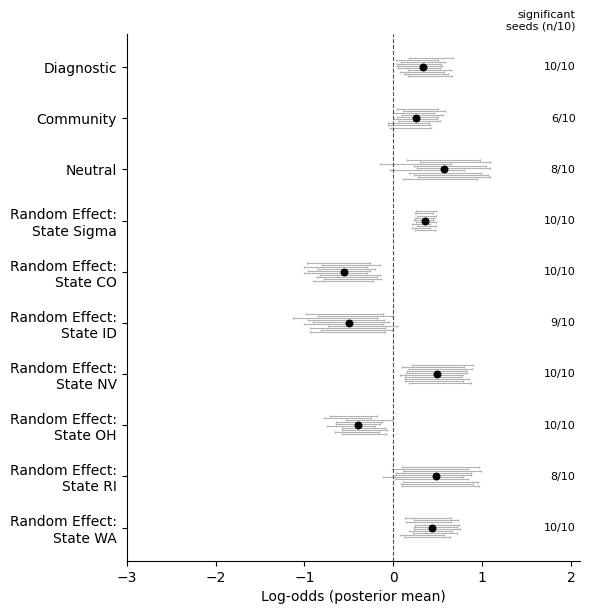

In [ ]:
df_allseeds = df_allseeds.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6, 0.6 * len(df_allseeds)))

y = np.arange(len(df_allseeds))

# ---- Seed-level HDIs (thin, light grey) ----
seed_cols = [(f"mean_seed{i}", f"hdi_5%_seed{i}", f"hdi_95%_seed{i}") for i in seed_list]

offsets = np.linspace(-0.18, 0.18, len(seed_cols))

for (mean_col, low_col, high_col), off in zip(seed_cols, offsets):
    seed_means = df_allseeds[mean_col]
    seed_low = df_allseeds[low_col]
    seed_high = df_allseeds[high_col]

    lower = seed_means - seed_low
    upper = seed_high - seed_means

    ax.errorbar(
        seed_means,
        y + off,
        xerr=[lower, upper],
        fmt='none',
        ecolor='0.7',       # grayscale-safe
        elinewidth=0.8,
        capsize=1,
        zorder=1
    )

# ---- Across-seed posterior mean (dominant) ----
mean_across = df_allseeds["mean_across_seeds"]

ax.scatter(
    mean_across,
    y,
    c='black',
    s=22,
    zorder=3
)

# ---- Zero reference line ----
ax.axvline(0, color='0.3', linestyle='--', linewidth=0.8)

# ---- Axis formatting ----
ax.set_yticks(y)
ax.set_yticklabels(df_allseeds["variable"])
ax.set_xlabel("Log-odds (posterior mean)")

ax.set_xlim(-3, 2.1)

sns.despine()

plt.tight_layout()

# ---- annotate: significant seeds ----
x_text = ax.get_xlim()[1] - 0.05  # right margin

for i, count in enumerate(df_allseeds["sig_seed_count"]):
    ax.text(
        x_text,
        i,
        f"{count}/{len(seed_list)}",
        va='center',
        ha='right',
        fontsize=8,
        color='black'
    )

# optional column label at top
ax.text(
    x_text,
    len(y) - 0.3,
    f"significant\nseeds (n/{len(seed_list)})",
    ha='right',
    va='bottom',
    fontsize=8
)

plt.savefig("../data/plots/bayesian_model_coefficients_rolling5_onlydiag.svg")



## Rolling window = 5, only prog

In [261]:
rolling_window = 5

In [262]:
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [263]:
variables_toplot = [
    #'Intercept',
    'prog_prop',
 'comm_prop',
 # 'fear_prob',
 #'joy_prob',
 'neutral_prob',
 '1|election_state[CO]', '1|election_state[NV]', '1|election_state[RI]', '1|election_state[WA]', 
 '1|election_state[ID]', '1|election_state[OH]', '1|election_state_sigma'
 ]

In [ ]:
# variables_toplot = ['prog_prop', 'mot_prop', 'comm_prop', 'eng_prop',
#  'anger_prob', 'disgust_prob', 'fear_prob', 'joy_prob','neutral_prob',
#  'sadness_prob', 'surprise_prob', 'standardize(size)', 'standardize(assets)',
#  'standardize(Disbursement)', 'standardize(Liabilities)',
#  'standardize(weekly_posts_mean)', 'primary_industry[Construction]',
#  'primary_industry[Educational Services]',
#  'primary_industry[Federal Government]',
#  'primary_industry[Health Care and Social Assistance]',
#  'primary_industry[Manufacturing]', 'primary_industry[Maritime]',
#  'primary_industry[Personal Serv & Private Organizations]',
#  'primary_industry[Retail Trade]', 'primary_industry[Transportation]',
#  'primary_industry[Transportation and Warehousing]',
#  'primary_industry[Utilities]', 'type[Industrial]', 'rightwork',
#  '1|union_sigma', '1|election_state_sigma', '1|union[afm]', '1|union[afscme]',
#  '1|union[aft]', '1|union[atu]', '1|union[bac]', '1|union[bctgm]',
#  '1|union[cwa]', '1|union[iaff]', '1|union[iam]', '1|union[iatse]',
#  '1|union[ibb]', '1|union[ibew]', '1|union[ibt]', '1|union[ifpte]',
#  '1|union[ironworkers]', '1|union[iupat]', '1|union[liuna]', '1|union[natca]',
#  '1|union[nea]', '1|union[nnu]', '1|union[opeiu]', '1|union[seiu]',
#  '1|union[siu]', '1|union[smart]', '1|union[twu]', '1|union[ua]',
#  '1|union[uaw]', '1|union[ufcw]', '1|union[unite here]', '1|union[usw]',
#  '1|union[uwua]', '1|election_state[AK]', '1|election_state[AL]',
#  '1|election_state[AR]', '1|election_state[AZ]', '1|election_state[CA]',
#  '1|election_state[CO]', '1|election_state[CT]', '1|election_state[DC]',
#  '1|election_state[DE]', '1|election_state[FL]', '1|election_state[GA]',
#  '1|election_state[GU]', '1|election_state[HI]', '1|election_state[IA]',
#  '1|election_state[ID]', '1|election_state[IL]', '1|election_state[IN]',
#  '1|election_state[KS]', '1|election_state[KY]', '1|election_state[LA]',
#  '1|election_state[MA]', '1|election_state[MD]', '1|election_state[ME]',
#  '1|election_state[MI]', '1|election_state[MN]', '1|election_state[MO]',
#  '1|election_state[MS]', '1|election_state[MT]', '1|election_state[NC]',
#  '1|election_state[ND]', '1|election_state[NE]', '1|election_state[NH]',
#  '1|election_state[NJ]', '1|election_state[NM]', '1|election_state[NV]',
#  '1|election_state[NY]', '1|election_state[OH]', '1|election_state[OK]',
#  '1|election_state[OR]', '1|election_state[PA]', '1|election_state[PR]',
#  '1|election_state[RI]', '1|election_state[SC]', '1|election_state[SD]',
#  '1|election_state[TN]', '1|election_state[TX]', '1|election_state[UT]',
#  '1|election_state[VA]', '1|election_state[VI]', '1|election_state[VT]',
#  '1|election_state[WA]', '1|election_state[WI]', '1|election_state[WV]',
#  '1|election_state[WY]']

In [ ]:
first = True
for seed in seed_list:
    df = pd.read_csv(f"../data/bayesian_model_summary-rolling_prog_window_{rolling_window}_seed{seed}-moredata_staterandom.csv")

    if df.columns[0] != "variable":
        df = df.rename(columns={df.columns[0]: "variable"})

    if first:
        df_allseeds = df[df["variable"].isin(variables_toplot)]
        first = False
        # rename all columns except "variable" to have suffix _seed{seed}
    else:
        df_allseeds = df_allseeds.merge(df[df["variable"].isin(variables_toplot)], on="variable", suffixes=('', f'_seed{seed}'), how='outer')

    df_allseeds = df_allseeds.rename(columns={col: f"{col}_seed{seed}" for col in df_allseeds.columns if (col != "variable" and "seed" not in col)})

In [265]:
# for all variables, compute the mean across seeds 
list_means = []
for var in df_allseeds["variable"]:
    means = []
    for seed in seed_list:
        means.append(df_allseeds.loc[df_allseeds["variable"] == var, f"mean_seed{seed}"].values[0])
    mean_across_seeds = np.mean(means)
    list_means.append({"variable": var, "mean_across_seeds": mean_across_seeds})

In [266]:
df_allseeds["mean_across_seeds"] = [item["mean_across_seeds"] for item in list_means]

In [267]:
# rename variables for plotting
df_allseeds["variable"] = df_allseeds["variable"].replace({
    "prog_prop": "Prognostic",
    "mot_prop": "Motivational",
    "comm_prop": "Community",
    "eng_prop": "Engagement",
    "disgust_prob": "Disgust",
    "neutral_prob": "Neutral",
    "anger_prob": "Anger",
    "1|election_state[CO]": "Random Effect:\nState CO", 
    "1|election_state[ID]": "Random Effect:\nState ID",
    "1|election_state[OH]": "Random Effect:\nState OH",
    "1|election_state[NV]": "Random Effect:\nState NV",
    "1|election_state[RI]": "Random Effect:\nState RI",
    "1|election_state[WA]": "Random Effect:\nState WA",
    "1|election_state_sigma": "Random Effect:\nState Sigma"})

In [268]:
# ---- count significant seeds per variable ----
sig_counts = []

for idx in range(len(df_allseeds)):
    count = 0
    for i in seed_list:
        low = df_allseeds.loc[idx, f"hdi_5%_seed{i}"]
        high = df_allseeds.loc[idx, f"hdi_95%_seed{i}"]

        # significant if interval excludes 0
        if (low > 0) or (high < 0):
            count += 1

    sig_counts.append(count)

df_allseeds["sig_seed_count"] = sig_counts

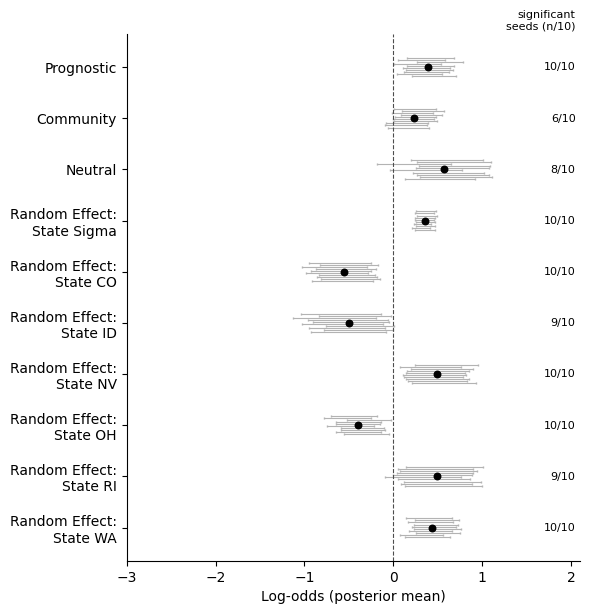

In [ ]:
df_allseeds = df_allseeds.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6, 0.6 * len(df_allseeds)))

y = np.arange(len(df_allseeds))

# ---- Seed-level HDIs (thin, light grey) ----
seed_cols = [(f"mean_seed{i}", f"hdi_5%_seed{i}", f"hdi_95%_seed{i}") for i in seed_list]

offsets = np.linspace(-0.18, 0.18, len(seed_cols))

for (mean_col, low_col, high_col), off in zip(seed_cols, offsets):
    seed_means = df_allseeds[mean_col]
    seed_low = df_allseeds[low_col]
    seed_high = df_allseeds[high_col]

    lower = seed_means - seed_low
    upper = seed_high - seed_means

    ax.errorbar(
        seed_means,
        y + off,
        xerr=[lower, upper],
        fmt='none',
        ecolor='0.7',       # grayscale-safe
        elinewidth=0.8,
        capsize=1,
        zorder=1
    )

# ---- Across-seed posterior mean (dominant) ----
mean_across = df_allseeds["mean_across_seeds"]

ax.scatter(
    mean_across,
    y,
    c='black',
    s=22,
    zorder=3
)

# ---- Zero reference line ----
ax.axvline(0, color='0.3', linestyle='--', linewidth=0.8)

# ---- Axis formatting ----
ax.set_yticks(y)
ax.set_yticklabels(df_allseeds["variable"])
ax.set_xlabel("Log-odds (posterior mean)")

ax.set_xlim(-3, 2.1)

sns.despine()

plt.tight_layout()

# ---- annotate: significant seeds ----
x_text = ax.get_xlim()[1] - 0.05  # right margin

for i, count in enumerate(df_allseeds["sig_seed_count"]):
    ax.text(
        x_text,
        i,
        f"{count}/{len(seed_list)}",
        va='center',
        ha='right',
        fontsize=8,
        color='black'
    )

# optional column label at top
ax.text(
    x_text,
    len(y) - 0.3,
    f"significant\nseeds (n/{len(seed_list)})",
    ha='right',
    va='bottom',
    fontsize=8
)

plt.savefig("../data/plots/bayesian_model_coefficients_rolling5_onlyprog.svg")



## Rolling window = 5, downsampling for overly active unions

In [278]:
rolling_window = 5

In [279]:
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [280]:

variables_toplot = ['diagprog_prop', 'comm_prop', 
                    '1|election_state_sigma', '1|election_state[CA]',
                    '1|election_state[CO]', 
                    '1|election_state[OH]', '1|election_state[WA]']
# variables_toplot = ['Intercept', 'diagprog_prop', 'mot_prop', 'comm_prop', 'eng_prop',
#  'anger_prob', 'disgust_prob', 'fear_prob', 'joy_prob','neutral_prob',
#  'sadness_prob', 'surprise_prob', 'standardize(size)', 'standardize(assets)',
#  'standardize(Disbursement)', 'standardize(Liabilities)',
#  'standardize(weekly_posts_mean)', 'primary_industry[Construction]',
#  'primary_industry[Educational Services]',
#  'primary_industry[Federal Government]',
#  'primary_industry[Health Care and Social Assistance]',
#  'primary_industry[Manufacturing]', 'primary_industry[Maritime]',
#  'primary_industry[Personal Serv & Private Organizations]',
#  'primary_industry[Retail Trade]', 'primary_industry[Transportation]',
#  'primary_industry[Transportation and Warehousing]',
#  'primary_industry[Utilities]', 'type[Industrial]', 'rightwork',
#  '1|union_sigma', '1|election_state_sigma', '1|union[afm]', '1|union[afscme]',
#  '1|union[aft]', '1|union[atu]', '1|union[bac]', '1|union[bctgm]',
#  '1|union[cwa]', '1|union[iaff]', '1|union[iam]', '1|union[iatse]',
#  '1|union[ibb]', '1|union[ibew]', '1|union[ibt]', '1|union[ifpte]',
#  '1|union[ironworkers]', '1|union[iupat]', '1|union[liuna]', '1|union[natca]',
#  '1|union[nea]', '1|union[nnu]', '1|union[opeiu]', '1|union[seiu]',
#  '1|union[siu]', '1|union[smart]', '1|union[twu]', '1|union[ua]',
#  '1|union[uaw]', '1|union[ufcw]', '1|union[unite here]', '1|union[usw]',
#  '1|union[uwua]', '1|election_state[AK]', '1|election_state[AL]',
#  '1|election_state[AR]', '1|election_state[AZ]', '1|election_state[CA]',
#  '1|election_state[CO]', '1|election_state[CT]', '1|election_state[DC]',
#  '1|election_state[DE]', '1|election_state[FL]', '1|election_state[GA]',
#  '1|election_state[GU]', '1|election_state[HI]', '1|election_state[IA]',
#  '1|election_state[ID]', '1|election_state[IL]', '1|election_state[IN]',
#  '1|election_state[KS]', '1|election_state[KY]', '1|election_state[LA]',
#  '1|election_state[MA]', '1|election_state[MD]', '1|election_state[ME]',
#  '1|election_state[MI]', '1|election_state[MN]', '1|election_state[MO]',
#  '1|election_state[MS]', '1|election_state[MT]', '1|election_state[NC]',
#  '1|election_state[ND]', '1|election_state[NE]', '1|election_state[NH]',
#  '1|election_state[NJ]', '1|election_state[NM]', '1|election_state[NV]',
#  '1|election_state[NY]', '1|election_state[OH]', '1|election_state[OK]',
#  '1|election_state[OR]', '1|election_state[PA]', '1|election_state[PR]',
#  '1|election_state[RI]', '1|election_state[SC]', '1|election_state[SD]',
#  '1|election_state[TN]', '1|election_state[TX]', '1|election_state[UT]',
#  '1|election_state[VA]', '1|election_state[VI]', '1|election_state[VT]',
#  '1|election_state[WA]', '1|election_state[WI]', '1|election_state[WV]',
#  '1|election_state[WY]']

In [ ]:
first = True
for seed in seed_list:
    df = pd.read_csv(f"../data/bayesian_model_summary-rolling_diag+prog_downsample_window_{rolling_window}_seed{seed}-moredata_staterandom.csv")

    if df.columns[0] != "variable":
        df = df.rename(columns={df.columns[0]: "variable"})

    if first:
        df_allseeds = df[df["variable"].isin(variables_toplot)]
        first = False
        # rename all columns except "variable" to have suffix _seed{seed}
    else:
        df_allseeds = df_allseeds.merge(df[df["variable"].isin(variables_toplot)], on="variable", suffixes=('', f'_seed{seed}'), how='outer')

    df_allseeds = df_allseeds.rename(columns={col: f"{col}_seed{seed}" for col in df_allseeds.columns if (col != "variable" and "seed" not in col)})

In [282]:
# for all variables, compute the mean across seeds 
list_means = []
for var in df_allseeds["variable"]:
    means = []
    for seed in seed_list:
        means.append(df_allseeds.loc[df_allseeds["variable"] == var, f"mean_seed{seed}"].values[0])
    mean_across_seeds = np.mean(means)
    list_means.append({"variable": var, "mean_across_seeds": mean_across_seeds})

In [283]:
df_allseeds["mean_across_seeds"] = [item["mean_across_seeds"] for item in list_means]

In [284]:
# rename variables for plotting
df_allseeds["variable"] = df_allseeds["variable"].replace({
    "diagprog_prop": "Diagnostic\nor Prognostic",
    "mot_prop": "Motivational",
    "comm_prop": "Community",
    "eng_prop": "Engagement",
    "disgust_prob": "Disgust",
    "neutral_prob": "Neutral",
    "anger_prob": "Anger",
    "1|election_state[CO]": "Random Effect:\nState CO", 
    "1|election_state[CA]": "Random Effect:\nState CA",
    "1|election_state[OH]": "Random Effect:\nState OH",
    "1|election_state[WA]": "Random Effect:\nState WA",
    "1|election_state_sigma": "Random Effect:\nState Sigma"})

In [285]:
# ---- count significant seeds per variable ----
sig_counts = []

for idx in range(len(df_allseeds)):
    count = 0
    for i in seed_list:
        low = df_allseeds.loc[idx, f"hdi_5%_seed{i}"]
        high = df_allseeds.loc[idx, f"hdi_95%_seed{i}"]

        # significant if interval excludes 0
        if (low > 0) or (high < 0):
            count += 1

    sig_counts.append(count)

df_allseeds["sig_seed_count"] = sig_counts

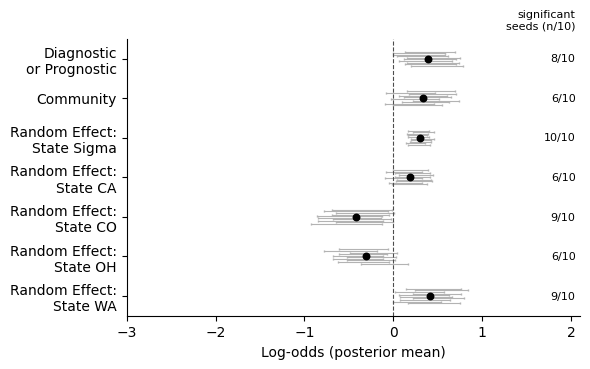

In [ ]:
df_allseeds = df_allseeds.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6, 0.5 * len(df_allseeds)))

y = np.arange(len(df_allseeds))

# ---- Seed-level HDIs (thin, light grey) ----
seed_cols = [(f"mean_seed{i}", f"hdi_5%_seed{i}", f"hdi_95%_seed{i}") for i in seed_list]

offsets = np.linspace(-0.18, 0.18, len(seed_cols))

for (mean_col, low_col, high_col), off in zip(seed_cols, offsets):
    seed_means = df_allseeds[mean_col]
    seed_low = df_allseeds[low_col]
    seed_high = df_allseeds[high_col]

    lower = seed_means - seed_low
    upper = seed_high - seed_means

    ax.errorbar(
        seed_means,
        y + off,
        xerr=[lower, upper],
        fmt='none',
        ecolor='0.7',       # grayscale-safe
        elinewidth=0.8,
        capsize=1,
        zorder=1
    )

# ---- Across-seed posterior mean (dominant) ----
mean_across = df_allseeds["mean_across_seeds"]

ax.scatter(
    mean_across,
    y,
    c='black',
    s=22,
    zorder=3
)

# ---- Zero reference line ----
ax.axvline(0, color='0.3', linestyle='--', linewidth=0.8)

# ---- Axis formatting ----
ax.set_yticks(y)
ax.set_yticklabels(df_allseeds["variable"])
ax.set_xlabel("Log-odds (posterior mean)")

ax.set_xlim(-3, 2.1)

sns.despine()

plt.tight_layout()

# ---- annotate: significant seeds ----
x_text = ax.get_xlim()[1] - 0.05  # right margin

for i, count in enumerate(df_allseeds["sig_seed_count"]):
    ax.text(
        x_text,
        i,
        f"{count}/{len(seed_list)}",
        va='center',
        ha='right',
        fontsize=8,
        color='black'
    )

# optional column label at top
ax.text(
    x_text,
    len(y) - 0.3,
    f"significant\nseeds (n/{len(seed_list)})",
    ha='right',
    va='bottom',
    fontsize=8
)

plt.savefig("../data/plots/bayesian_model_coefficients_rolling5_diagprog-balanced.svg")
